In [1]:
import os
import sys
os.environ['PYTHONWARNINGS'] = 'ignore'
class NullWriter:
    def write(self, msg):
        pass
    def flush(self):
        pass
sys.stderr = NullWriter()

In [2]:
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np
import celldyc as cdc, scvelo as scv,cellrank as cr
import wot
import moscot as mt

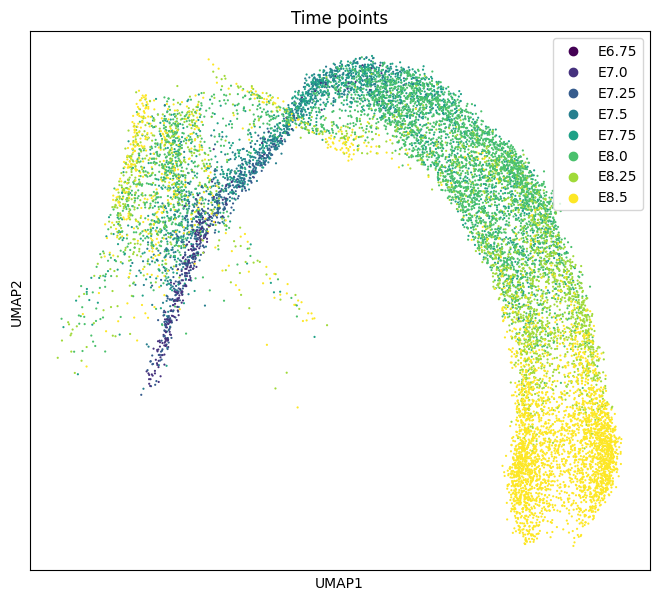

Training with early stop (max_epochs=500, patience=40)
epoch   1:loss=0.864613,trend_loss=0.851177,time_loss=0.134356
epoch  51:loss=0.667414,trend_loss=0.661974,time_loss=0.054399
epoch 101:loss=0.656995,trend_loss=0.651533,time_loss=0.054617
epoch 151:loss=0.657527,trend_loss=0.652122,time_loss=0.054050
epoch 201:loss=0.652532,trend_loss=0.647125,time_loss=0.054069
epoch 251:loss=0.650788,trend_loss=0.645402,time_loss=0.053857
epoch 301:loss=0.649185,trend_loss=0.643784,time_loss=0.054010
Early stopping at epoch 318


  0%|          | 0/12324 [00:00<?, ?cells/s]

computing velocity graph
finished.


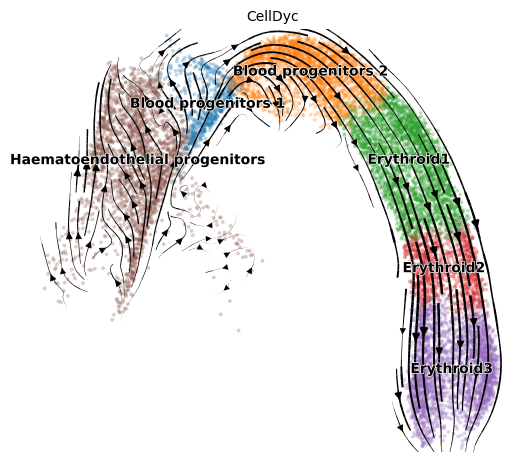

computing velocity embedding
finished.


In [3]:
adata = cdc.datasets.gastrulation()
fig, ax = plt.subplots(figsize=(8,7))
ax = sc.pl.embedding(
    adata,
    color=["stage"],
    basis="umap",
    ax=ax,
    title="Time points",
    legend_loc="upper right",
    palette="viridis",
)
adata = cdc.tl.preprocess(adata)
stage2hour = {
    'E6.75': 6.75,
    'E7.0': 7.0,
    'E7.25': 7.25,
    'E7.5': 7.5,
    'E7.75': 7.75,
    'E8.0': 8.0,
    'E8.25': 8.25,
    'E8.5': 8.5,
}
adata.obs['numerical_time'] = adata.obs['stage'].map(stage2hour).astype(float).astype('category')
adata.obs['celltype'] = adata.obs['celltype'].cat.reorder_categories(
    ['Haematoendothelial progenitors'] + 
    [cat for cat in adata.obs['celltype'].cat.categories 
     if cat != 'Haematoendothelial progenitors']
)
adata.uns['celltype_colors'] = cdc.settings.colormap["gastrulation"]
cdc.tl.recover_dyc(adata, time_key='numerical_time')
cdc.pl.plot_velocity_projection(adata, color='celltype', figsize=(6, 5.5), size=30,title="CellDyc")

In [4]:
adata_ct = cdc.datasets.gastrulation()
sc.pp.filter_genes(adata_ct, min_cells=10)
sc.pp.normalize_total(adata_ct)
sc.pp.log1p(adata_ct)
sc.pp.highly_variable_genes(adata_ct)
adata_ct.layers['spliced'] = adata_ct.X
adata_ct.layers['unspliced'] = adata_ct.X
scv.pp.moments(adata_ct)
ctk = cr.kernels.CytoTRACEKernel(adata_ct).compute_cytotrace()
adata.obs['ct_pseudotime'] = adata_ct.obs['ct_pseudotime']

computing neighbors
    finished (0:00:02) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:10) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)


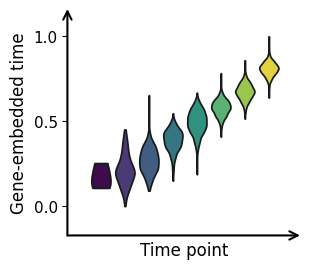

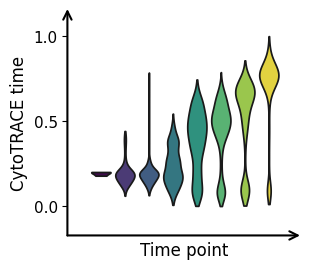

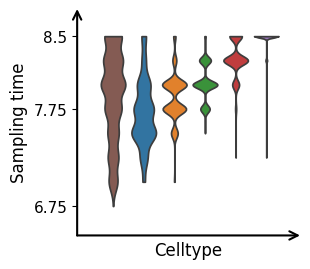

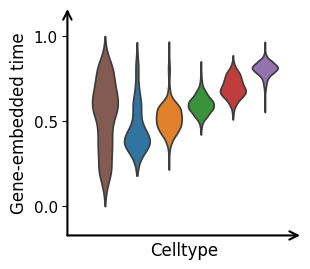

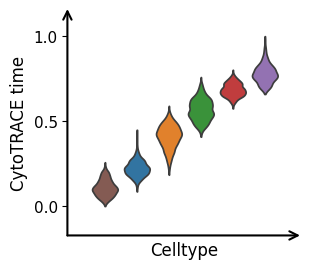

<Axes: xlabel='Celltype', ylabel='CytoTRACE time'>

In [5]:
stages = sorted(adata.obs["stage"].unique())
n_stages = len(stages)
viridis_colors = plt.cm.viridis(np.linspace(0, 1, n_stages))
color_dict = dict(zip(stages, viridis_colors))
cdc.pl.getime_violin(adata, "getime", "stage", palette=color_dict)
cdc.pl.getime_violin(adata, "ct_pseudotime", "stage", palette=color_dict)
cdc.pl.getime_violin(
    adata,
    "numerical_time",
    "celltype",
    palette=adata.uns["celltype_colors"],
    xlabel="Celltype",
    ylabel="Sampling time",
)
cdc.pl.getime_violin(
    adata,
    "getime",
    "celltype",
    palette=adata.uns["celltype_colors"],
    xlabel="Celltype",
)
cdc.pl.getime_violin(
    adata,
    "ct_pseudotime",
    "celltype",
    palette=adata.uns["celltype_colors"],
    xlabel="Celltype",
)


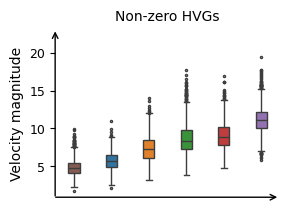

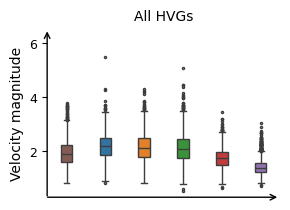

<Axes: title={'center': 'All HVGs'}, ylabel='Velocity magnitude'>

In [6]:
v = adata.layers["velocity"]                 
v_abs = np.abs(v)                            
mask_nonzero = v_abs > 0                     
nonzero_counts = mask_nonzero.sum(axis=1)   
nonzero_counts_safe = nonzero_counts.copy()
nonzero_counts_safe[nonzero_counts_safe == 0] = 1
v_abs_sum = v_abs.sum(axis=1)              
v_abs_mean = v_abs_sum / nonzero_counts_safe
v_abs_mean[nonzero_counts == 0] = 0         
adata.obs["velocity_abs_mean"] = v_abs_mean
cdc.rp.boxplot(adata,ylabel='Velocity magnitude',title="Non-zero HVGs")

v = adata.layers["velocity"]
v_abs = np.abs(v)
v_abs_mean_all = v_abs.mean(axis=1)
adata.obs["velocity_abs_mean_all"] = v_abs_mean_all
cdc.rp.boxplot(adata,ylabel='Velocity magnitude',y="velocity_abs_mean_all",title="All HVGs")


In [7]:
adata_scvelo = cdc.datasets.gastrulation()
adata_scvelo = cdc.tl.preprocess(adata_scvelo)
stage2hour = {
    'E6.75': 6.75,
    'E7.0': 7.0,
    'E7.25': 7.25,
    'E7.5': 7.5,
    'E7.75': 7.75,
    'E8.0': 8.0,
    'E8.25': 8.25,
    'E8.5': 8.5,
}
adata_scvelo.obs['numerical_time'] = adata_scvelo.obs['stage'].map(stage2hour).astype(float).astype('category')
adata_scvelo.obs['celltype'] = adata_scvelo.obs['celltype'].cat.reorder_categories(
    ['Haematoendothelial progenitors'] + 
    [cat for cat in adata_scvelo.obs['celltype'].cat.categories 
     if cat != 'Haematoendothelial progenitors']
)
adata_scvelo.uns['celltype_colors'] = cdc.settings.colormap["gastrulation"]
adata_wot = adata_scvelo.copy()
adata_moscot = adata_scvelo.copy()

Normalized count data: spliced, unspliced.
computing moments based on connectivities
    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
recovering dynamics (using 1/16 cores)


  0%|          | 0/598 [00:00<?, ?gene/s]

    finished (0:10:16) --> added 
    'fit_pars', fitted parameters for splicing dynamics (adata.var)
computing velocities
    finished (0:00:05) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 16/16 cores)


  0%|          | 0/12324 [00:00<?, ?cells/s]

    finished (0:00:17) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:02) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


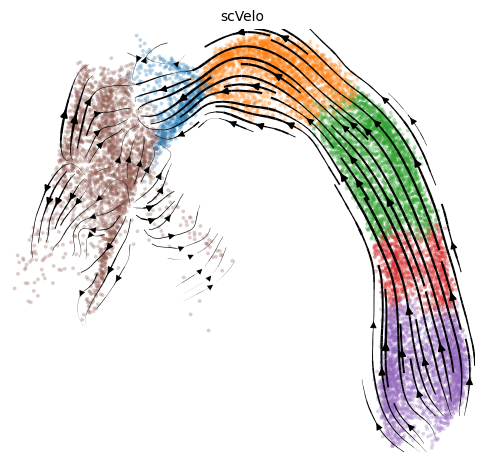

In [8]:
scv.pp.moments(adata_scvelo, n_pcs=30, n_neighbors=30)
scv.tl.recover_dynamics(adata_scvelo)
scv.tl.velocity(adata_scvelo, mode='dynamical', n_jobs=16)
scv.tl.velocity_graph(adata_scvelo, n_jobs=16)
scv.pl.velocity_embedding_stream(adata_scvelo,color='celltype',figsize=(6, 5.5),size=30,legend_loc='none',title='scVelo')

computing terminal states
    identified 10 regions of root cells and 1 region of end points .
    finished (0:00:01) --> added
    'root_cells', root cells of Markov diffusion process (adata.obs)
    'end_points', end points of Markov diffusion process (adata.obs)
computing latent time using root_cells as prior
    finished (0:00:01) --> added 
    'latent_time', shared time (adata.obs)


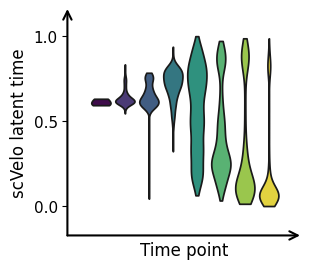

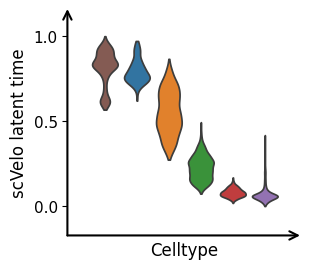

<Axes: xlabel='Celltype', ylabel='scVelo latent time'>

In [9]:
scv.tl.latent_time(adata_scvelo)
stages = sorted(adata_scvelo.obs['stage'].unique())
n_stages = len(stages)
viridis_colors = plt.cm.viridis(np.linspace(0, 1, n_stages))
color_dict = dict(zip(stages, viridis_colors))
cdc.pl.getime_violin(adata_scvelo,'latent_time','stage',palette=color_dict,ylabel="scVelo latent time")
cdc.pl.getime_violin(adata_scvelo,'latent_time','celltype',palette=adata_scvelo.uns["celltype_colors"],xlabel="Celltype",ylabel="scVelo latent time")

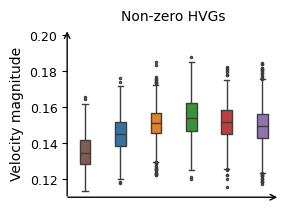

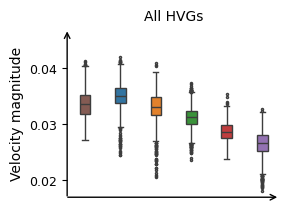

<Axes: title={'center': 'All HVGs'}, ylabel='Velocity magnitude'>

In [10]:
v = adata_scvelo.layers["velocity"]
v = np.nan_to_num(v, nan=0.0)                 
v_abs = np.abs(v)                            
mask_nonzero = v_abs > 0                     
nonzero_counts = mask_nonzero.sum(axis=1)   
nonzero_counts_safe = nonzero_counts.copy()
nonzero_counts_safe[nonzero_counts_safe == 0] = 1
v_abs_sum = v_abs.sum(axis=1)              
v_abs_mean = v_abs_sum / nonzero_counts_safe
v_abs_mean[nonzero_counts == 0] = 0         
adata_scvelo.obs["velocity_abs_mean"] = v_abs_mean
cdc.rp.boxplot(adata_scvelo,ylabel='Velocity magnitude',title="Non-zero HVGs")

v = adata_scvelo.layers["velocity"]
v = np.nan_to_num(v, nan=0.0)
v_abs = np.abs(v)
v_abs_mean_all = v_abs.mean(axis=1)
adata_scvelo.obs["velocity_abs_mean_all"] = v_abs_mean_all
cdc.rp.boxplot(adata_scvelo,ylabel='Velocity magnitude',y="velocity_abs_mean_all",title="All HVGs")


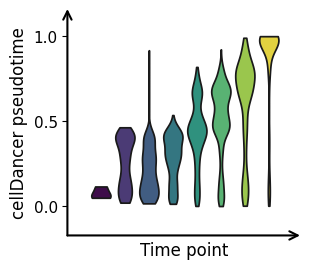

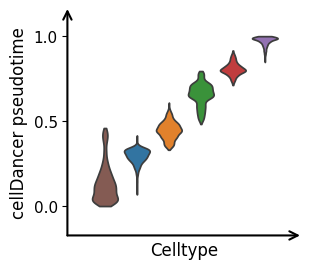

<Axes: xlabel='Celltype', ylabel='cellDancer pseudotime'>

In [ ]:
adata_celldancer=sc.read_h5ad("celldancer_gastrulation_erythropoiesis.h5ad")
adata_celldancer.obs['celltype'] = adata_celldancer.obs['celltype'].cat.reorder_categories(
    ['Haematoendothelial progenitors'] + 
    [cat for cat in adata_celldancer.obs['celltype'].cat.categories 
    if cat != 'Haematoendothelial progenitors']
)
adata_celldancer.uns['celltype_colors']={'Haematoendothelial progenitors':'#8c564b','Blood progenitors 1':'#1f77b4','Blood progenitors 2': '#ff7f0e','Erythroid1':'#2ca02c' ,'Erythroid2':'#d62728',  'Erythroid3':'#9467bd'}
stages = sorted(adata_celldancer.obs['stage'].unique())
n_stages = len(stages)
viridis_colors = plt.cm.viridis(np.linspace(0, 1, n_stages))
color_dict = dict(zip(stages, viridis_colors))
cdc.pl.getime_violin(adata_celldancer,'pseudotime','stage',palette=color_dict,ylabel="cellDancer pseudotime")
cdc.pl.getime_violin(adata_celldancer,'pseudotime','celltype',palette=adata_celldancer.uns["celltype_colors"],xlabel="Celltype",ylabel="cellDancer pseudotime")

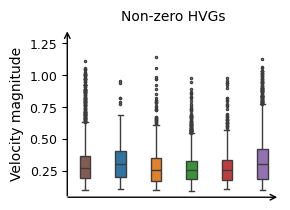

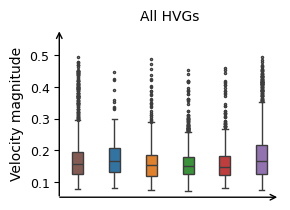

<Axes: title={'center': 'All HVGs'}, ylabel='Velocity magnitude'>

In [12]:
v = adata_celldancer.layers["velocity"]                 
v_abs = np.abs(v)                            
mask_nonzero = v_abs > 0                     
nonzero_counts = mask_nonzero.sum(axis=1)   
nonzero_counts_safe = nonzero_counts.copy()
nonzero_counts_safe[nonzero_counts_safe == 0] = 1
v_abs_sum = v_abs.sum(axis=1)              
v_abs_mean = v_abs_sum / nonzero_counts_safe
v_abs_mean[nonzero_counts == 0] = 0         
adata_celldancer.obs["velocity_abs_mean"] = v_abs_mean
cdc.rp.boxplot(adata_celldancer,ylabel='Velocity magnitude',title="Non-zero HVGs")

v = adata_celldancer.layers["velocity"]
v_abs = np.abs(v)
v_abs_mean_all = v_abs.mean(axis=1)
adata_celldancer.obs["velocity_abs_mean_all"] = v_abs_mean_all
cdc.rp.boxplot(adata_celldancer,ylabel='Velocity magnitude',y="velocity_abs_mean_all",title="All HVGs")

Only considering the two last: ['.0', '.h5ad'].
Only considering the two last: ['.0', '.h5ad'].
Only considering the two last: ['.25', '.h5ad'].
Only considering the two last: ['.25', '.h5ad'].
Only considering the two last: ['.5', '.h5ad'].
Only considering the two last: ['.5', '.h5ad'].
Only considering the two last: ['.75', '.h5ad'].
Only considering the two last: ['.75', '.h5ad'].
Only considering the two last: ['.0', '.h5ad'].
Only considering the two last: ['.0', '.h5ad'].
Only considering the two last: ['.25', '.h5ad'].
Only considering the two last: ['.25', '.h5ad'].
Only considering the two last: ['.5', '.h5ad'].
Only considering the two last: ['.5', '.h5ad'].


  0%|          | 0/7 [00:00<?, ?time pair/s]

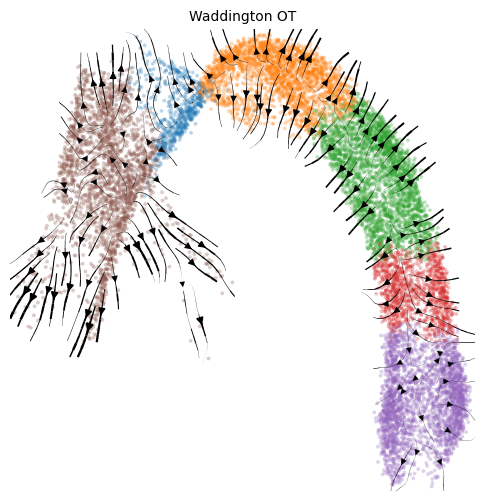

INFO     Computing pca with `n_comps=30` for `xy` using `adata.X`                                                  
INFO     Computing pca with `n_comps=30` for `xy` using `adata.X`                                                  
INFO     Computing pca with `n_comps=30` for `xy` using `adata.X`                                                  
INFO     Computing pca with `n_comps=30` for `xy` using `adata.X`                                                  
INFO     Computing pca with `n_comps=30` for `xy` using `adata.X`                                                  
INFO     Computing pca with `n_comps=30` for `xy` using `adata.X`                                                  
INFO     Computing pca with `n_comps=30` for `xy` using `adata.X`                                                  
INFO     Solving `7` problems                                                                                      
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(3, 2

  0%|          | 0/7 [00:00<?, ?time pair/s]

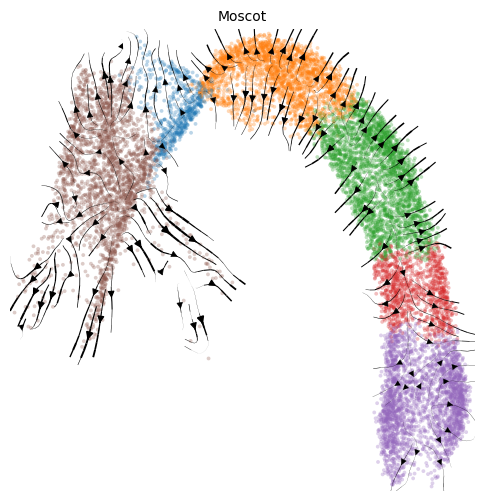

In [13]:
ot_model = wot.ot.OTModel(adata_wot, day_field="numerical_time")
ot_model.compute_all_transport_maps(tmap_out="gas/")
rtk = cr.kernels.RealTimeKernel.from_wot(adata_wot, path="gas/", time_key="numerical_time")
rtk = rtk.compute_transition_matrix()
with plt.rc_context({'axes.grid': False, 'grid.linewidth': 0}):
    rtk.plot_projection(basis="umap",connectivities=adata_wot.obsp["connectivities"],color="celltype", frameon=False, legend_loc="none",show=False,size=30,figsize=(6, 6),title="Waddington OT")
fig = plt.gcf()
for ax in fig.axes[1:]:  
    ax.remove()
plt.show()

problem = mt.problems.TemporalProblem(adata_moscot)
problem = problem.prepare(time_key="numerical_time").solve()
rtk = cr.kernels.RealTimeKernel.from_moscot(problem)
rtk = rtk.compute_transition_matrix()
with plt.rc_context({'axes.grid': False, 'grid.linewidth': 0}):
    rtk.plot_projection(basis="umap",connectivities=adata_moscot.obsp["connectivities"],color="celltype", frameon=False, legend_loc="none",show=False,size=30,figsize=(6,6),title="Moscot")
fig = plt.gcf()
for ax in fig.axes[1:]:  
    ax.remove()
plt.show()